In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 12
np.random.seed(12345)

In [8]:
def optimal_bins(data_vector):
    """Определение числа интервалов по правилу Фридмана-Диакониса"""
    q75, q25 = np.percentile(data_vector, [75, 25])
    iqr = q75 - q25
    if iqr > 0:
        bin_width = 2 * iqr / (len(data_vector) ** (1/3))
        n_bins = int((np.max(data_vector) - np.min(data_vector)) / bin_width)
    else:
        n_bins = int(np.sqrt(len(data_vector)))
    return max(5, min(n_bins, 30))

def theoretical_curve(dist_type, x_range):
    """Получение теоретической плотности"""
    if dist_type == 'gauss':
        return stats.norm.pdf(x_range, 0, 1)
    elif dist_type == 'cauchy':
        return stats.cauchy.pdf(x_range, 0, 1)
    elif dist_type == 'laplace':
        return stats.laplace.pdf(x_range, 0, 1/np.sqrt(2))
    elif dist_type == 'uniform':
        return stats.uniform.pdf(x_range, -np.sqrt(3), 2*np.sqrt(3))
    else:
        return None

def calculate_all_stats(sample_array):
    """Вычисление всех статистик для одной выборки"""
    sorted_vals = np.sort(sample_array)
    n = len(sorted_vals)
    cut = int(0.1 * n)
    
    mean_val = np.mean(sample_array)
    median_val = np.median(sample_array)
    extreme_half = (sorted_vals[0] + sorted_vals[-1]) / 2
    quartile_half = (np.percentile(sample_array, 25) + np.percentile(sample_array, 75)) / 2
    
    if n > 2 * cut:
        trimmed_mean = np.mean(sorted_vals[cut:n-cut])
    else:
        trimmed_mean = median_val
    
    return {
        'x_mean': mean_val,
        'x_med': median_val,
        'x_zr': extreme_half,
        'x_zq': quartile_half,
        'x_ztr': trimmed_mean
    }

def print_table(dist_name, data_dict):
    print(f"\n{dist_name}")
    print("=" * 75)
    print(f"{'Статистика':<15} {'n=10':>10} {'n=100':>10} {'n=1000':>10}")
    print("=" * 75)
    
    stats_ru = {
        'x_mean': 'Среднее',
        'x_med': 'Медиана', 
        'x_zr': 'Z_R',
        'x_zq': 'Z_Q',
        'x_ztr': 'Z_tr'
    }
    
    for stat_key, stat_name in stats_ru.items():
        line = f"{stat_name:<20}"
        for n_val in [10, 100, 1000]:
            mean_val = data_dict[n_val][stat_key]['mean']
            std_val = np.sqrt(data_dict[n_val][stat_key]['var'])
            line += f"{mean_val:>5.1f}±{std_val:<4.1f}   "
        print(line)
    print("=" * 75)

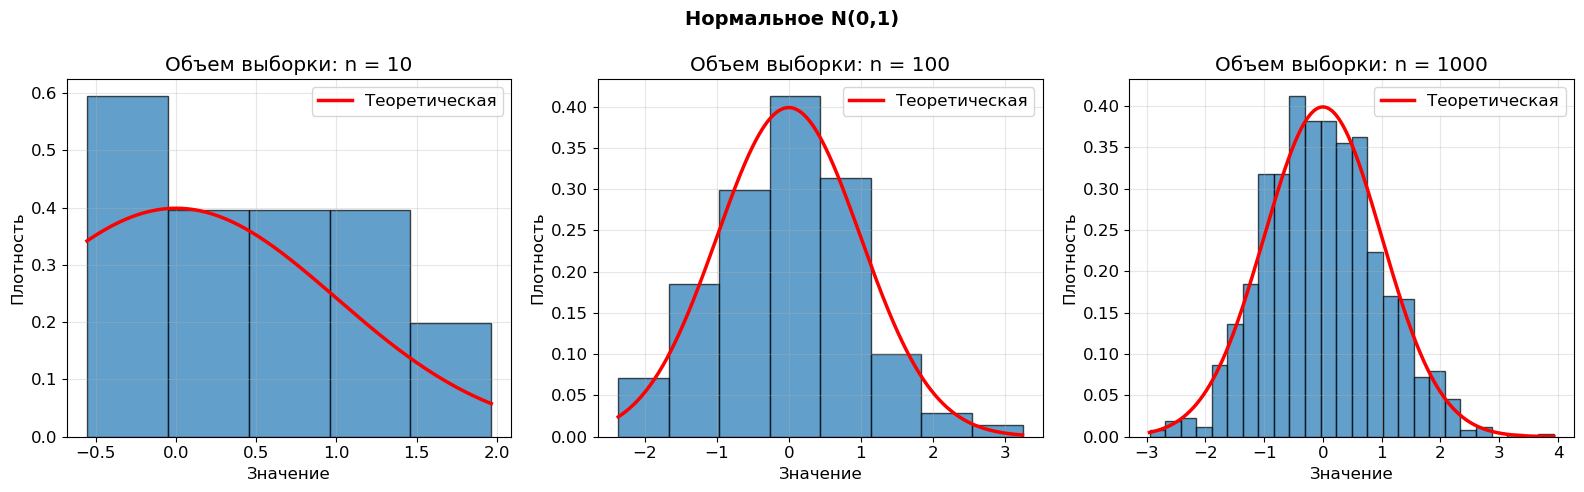

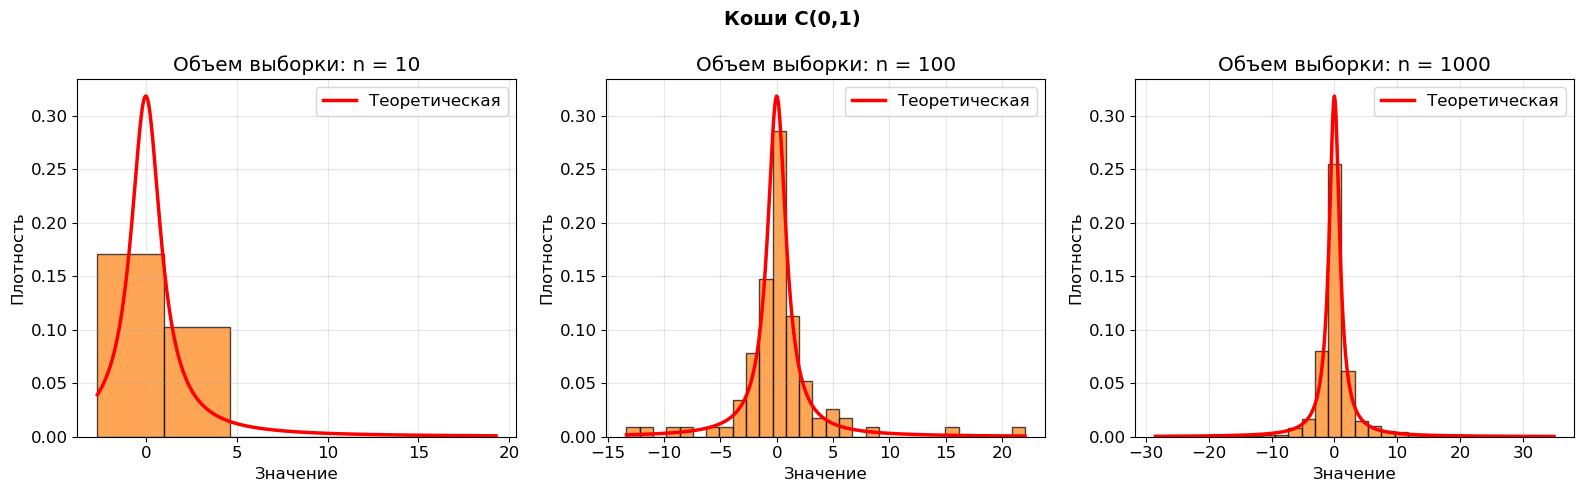

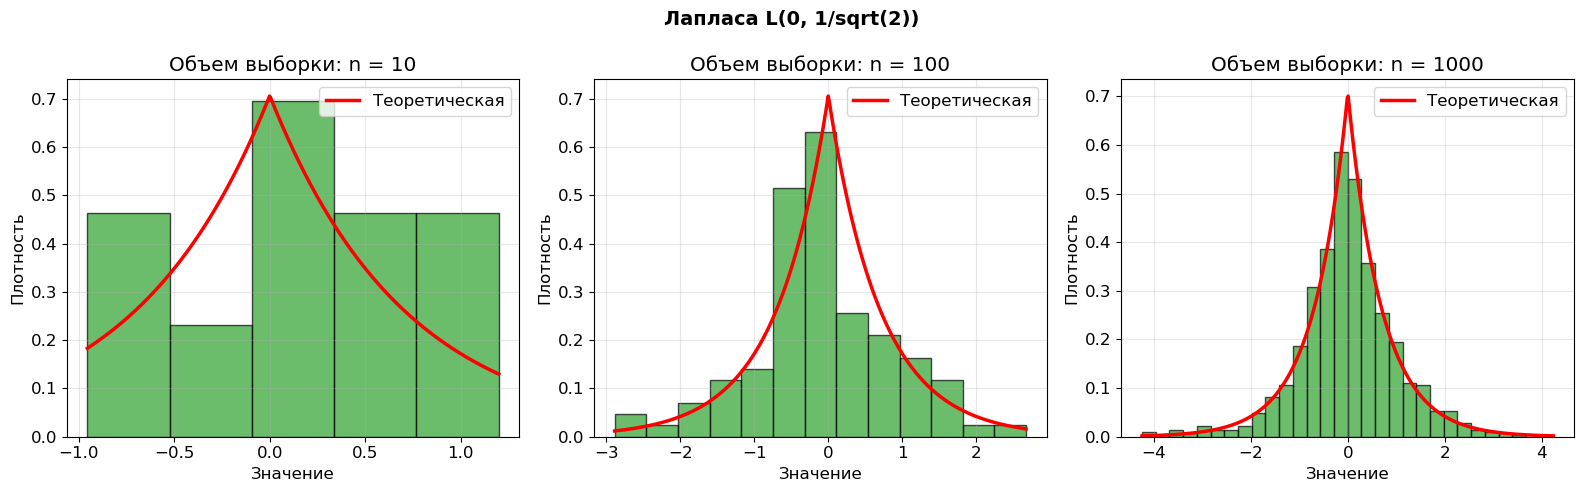

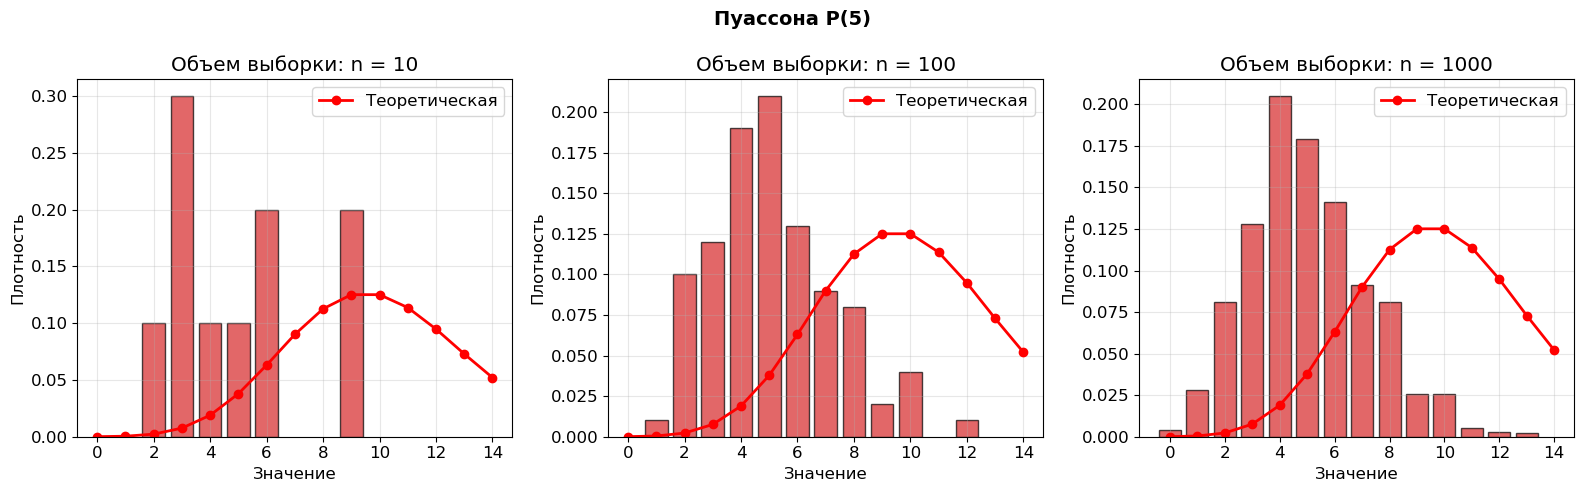

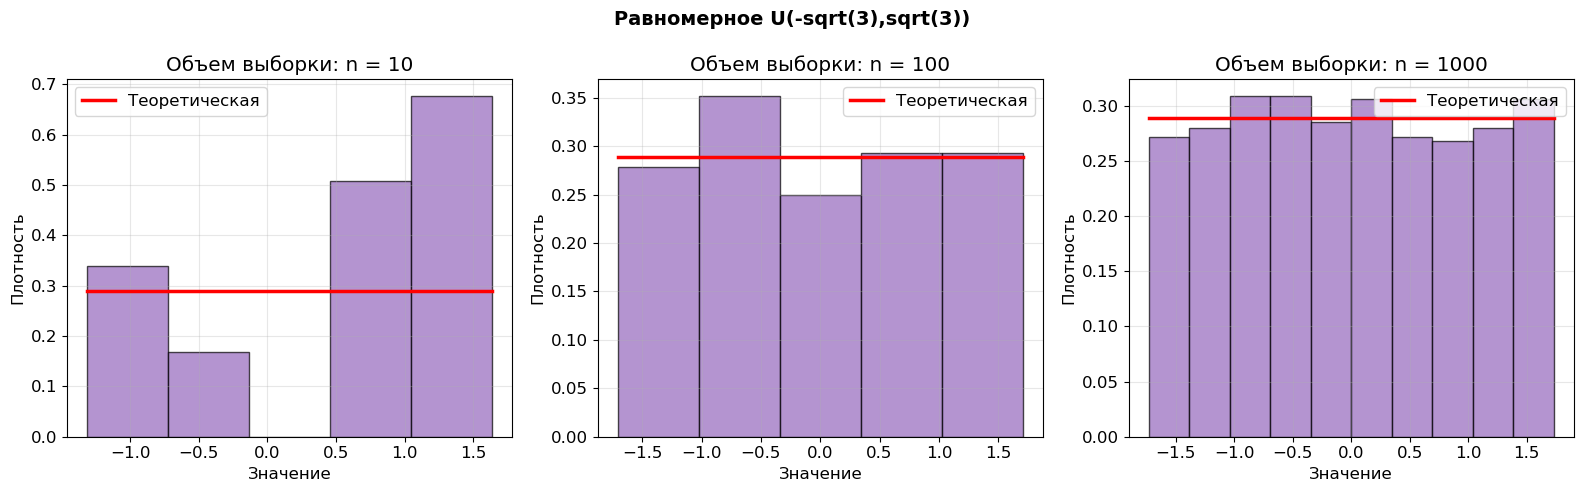

In [11]:
sample_sizes = [10, 100, 1000]
repeat_count = 1000

distributions = {
    'gauss': {
        'name': 'Нормальное N(0,1)',
        'generator': lambda n: np.random.normal(0, 1, n),
        'color': '#1f77b4'
    },
    'cauchy': {
        'name': 'Коши C(0,1)',
        'generator': lambda n: np.random.standard_cauchy(n),
        'color': '#ff7f0e'
    },
    'laplace': {
        'name': 'Лапласа L(0, 1/sqrt(2))',
        'generator': lambda n: np.random.laplace(0, 1/np.sqrt(2), n),
        'color': '#2ca02c'
    },
    'poisson': {
        'name': 'Пуассона P(5)',
        'generator': lambda n: np.random.poisson(5, n),
        'color': '#d62728',
        'discrete': True
    },
    'uniform': {
        'name': 'Равномерное U(-sqrt(3),sqrt(3))',
        'generator': lambda n: np.random.uniform(-np.sqrt(3), np.sqrt(3), n),
        'color': '#9467bd'
    }
}

for dist_key, dist_info in distributions.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{dist_info["name"]}', fontsize=14, fontweight='bold')
    
    for idx, n in enumerate(sample_sizes):
        sample_data = dist_info['generator'](n)
        
        # границы для графика
        if dist_key == 'cauchy':
            x_min, x_max = np.percentile(sample_data, [1, 99])
        else:
            x_min, x_max = np.min(sample_data), np.max(sample_data)
        
        # гистограмма
        if dist_key == 'poisson':
            # Для Пуассона - столбчатая диаграмма
            values, counts = np.unique(sample_data, return_counts=True)
            axes[idx].bar(values, counts/n, width=0.8, 
                         color=dist_info['color'], alpha=0.7, edgecolor='black')

            x_theor = np.arange(0, 15)
            y_theor = stats.poisson.pmf(x_theor, 10)
            axes[idx].plot(x_theor, y_theor, 'ro-', markersize=6, 
                          linewidth=2, label='Теоретическая')
        else:
            # Для непрерывных распределений
            bins_count = optimal_bins(sample_data)
            axes[idx].hist(sample_data, bins=bins_count, range=(x_min, x_max),
                          density=True, color=dist_info['color'], 
                          alpha=0.7, edgecolor='black')
            
            # Теоретическая кривая
            x_plot = np.linspace(x_min, x_max, 500)
            y_plot = theoretical_curve(dist_key, x_plot)
            axes[idx].plot(x_plot, y_plot, 'r-', linewidth=2.5, 
                          label='Теоретическая')
        
        axes[idx].set_xlabel('Значение')
        axes[idx].set_ylabel('Плотность')
        axes[idx].set_title(f'Объем выборки: n = {n}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

In [13]:
final_results = {}

for dist_key, dist_info in distributions.items():   
    results_by_n = {}
    
    for n in sample_sizes:
        stats_collection = {
            'x_mean': [],
            'x_med': [],
            'x_zr': [],
            'x_zq': [],
            'x_ztr': []
        }
        
        for _ in range(repeat_count):
            sample = dist_info['generator'](n)
            current_stats = calculate_all_stats(sample)
            
            for key in stats_collection:
                stats_collection[key].append(current_stats[key])
        
        # средние и дисперсии
        results_by_n[n] = {}
        for key in stats_collection:
            values = np.array(stats_collection[key])
            results_by_n[n][key] = {
                'mean': np.mean(values),
                'var': np.var(values, ddof=1)
            }
    
    final_results[dist_key] = results_by_n
    print_table(dist_info['name'], results_by_n)


Нормальное N(0,1)
Статистика            n=10      n=100     n=1000
Среднее               0.0±0.3     -0.0±0.1      0.0±0.0    
Медиана               0.0±0.4     -0.0±0.1      0.0±0.0    
Z_R                   0.0±0.4      0.0±0.3      0.0±0.2    
Z_Q                  -0.0±0.3     -0.0±0.1      0.0±0.0    
Z_tr                  0.0±0.3     -0.0±0.1      0.0±0.0    

Коши C(0,1)
Статистика            n=10      n=100     n=1000
Среднее              -1.2±69.1    -0.1±42.2     8.2±251.1   
Медиана              -0.0±0.6     -0.0±0.2     -0.0±0.1    
Z_R                  -5.7±344.8    -5.9±2089.8   4070.7±125537.5   
Z_Q                  -0.0±0.9      0.0±0.2     -0.0±0.1    
Z_tr                 -0.0±1.2      0.0±0.2     -0.0±0.1    

Лапласа L(0, 1/sqrt(2))
Статистика            n=10      n=100     n=1000
Среднее               0.0±0.3      0.0±0.1      0.0±0.0    
Медиана               0.0±0.3      0.0±0.1      0.0±0.0    
Z_R                   0.0±0.7     -0.0±0.6      0.0±0.7    
Z_Q    